In [2]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as seaborn

# Download latest version
path = kagglehub.dataset_download("yasserh/housing-prices-dataset")

print("Path to dataset files:", path)

import os
df_path = os.path.join(path, 'Housing.csv')
df = pd.read_csv(df_path)

100%|██████████| 4.63k/4.63k [00:00<00:00, 943kB/s]

Extracting files...
Path to dataset files: C:\Users\Admin\.cache\kagglehub\datasets\yasserh\housing-prices-dataset\versions\1


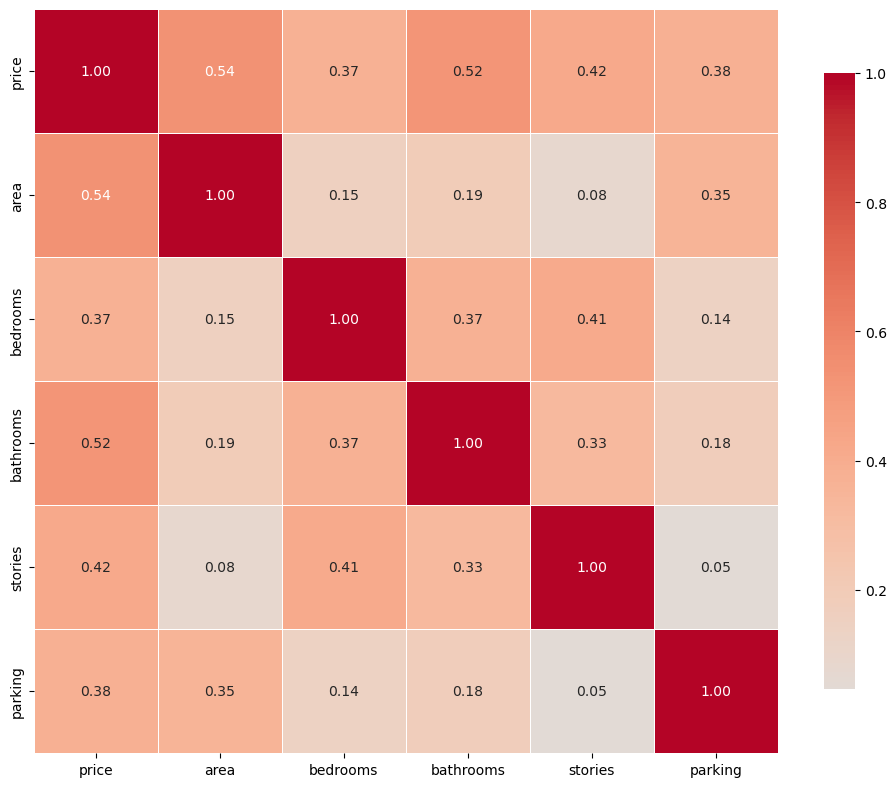

In [3]:
numeric_cols = df.select_dtypes(include=[np.number])
corr_matrix = numeric_cols.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, 
            annot=True, 
            cmap='coolwarm', 
            center=0,
            fmt='.2f',
            linewidths=0.5,
            square=True,
            cbar_kws={"shrink": 0.8})


plt.show()

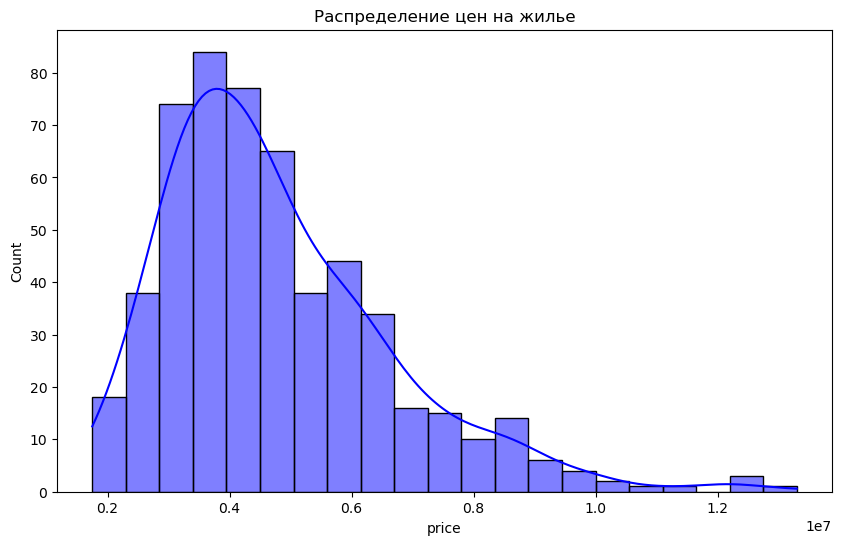

In [4]:
plt.figure(figsize=(10, 6))
sns.histplot(df['price'], kde=True, color='blue')
plt.title('Распределение цен на жилье')
plt.show()

In [5]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
columns = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']
for col in columns:
    df[col] = le.fit_transform(df[col])

In [6]:
from sklearn.model_selection import train_test_split

y = df['price']
X = df.drop('price', axis=1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42
)

In [7]:
from sklearn.ensemble import RandomForestRegressor

rf_main = RandomForestRegressor(n_estimators=100, random_state=0)
rf_main.fit(X_train, y_train)




,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [8]:
from xgboost import XGBRegressor


xgb_model = XGBRegressor(
    n_estimators=100,    
    learning_rate=0.1,  
    max_depth=5,         
    random_state=42      
)

xgb_model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [9]:
from sklearn.metrics import r2_score

r2_rf = r2_score(y_test, rf_main.predict(X_test))
r2_xgb = r2_score(y_test, xgb_model.predict(X_test))

print(f"R² rf: {r2_rf:.4f}")
print(f"R² xgb: {r2_xgb:.4f}")

R² rf: 0.6279
R² xgb: 0.6498


In [10]:
from catboost import CatBoostRegressor

cb = CatBoostRegressor(
    n_estimators=100,      
    learning_rate=0.1,    
    verbose=False,         # не выводить лог обучения 
    random_state=42        
)

cb.fit(X_train, y_train)
r2_cb = r2_score(y_test, cb.predict(X_test))

print(f"Точность CatBoost: {r2_cb:.4f}")

Точность CatBoost: 0.6371


In [11]:
import lightgbm as lgb

lgbm = lgb.LGBMRegressor(
    n_estimators=100, 
    learning_rate=0.1, 
    min_child_samples=5,  # Позволяет создавать ветки даже для 5 домов (по умолчанию 20)
    num_leaves=15,        # Ограничиваем количество листьев
    verbose=-1            # Убирает предупреждения из вывода
)
lgbm.fit(X_train, y_train)
r2_lgbm = r2_score(y_test, lgbm.predict(X_test))
print(f"Точность lgbm {r2_lgbm:.4f}")

Точность lgbm 0.6254


In [12]:
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,1,0,1,0,0,2,0,2
541,1767150,2400,3,1,1,0,0,0,0,0,0,0,1
542,1750000,3620,2,1,1,1,0,0,0,0,0,0,2
543,1750000,2910,3,1,1,0,0,0,0,0,0,0,0


In [18]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler

scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)


scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1)).ravel()



# Создаем модель
model = keras.Sequential([
    keras.layers.Dense(8, activation='relu', input_shape=(12,)),
    keras.layers.Dense(8, activation='relu'),
    keras.layers.Dense(1)
])

# Визуализируем архитектуру
model.summary()



model.compile(optimizer='adam',
              loss='mse',
              metrics=['mae'])

model.fit(X_train_scaled, y_train_scaled, 
          validation_split=0.15, 
          batch_size=16, 
          epochs=200, 
          verbose=0)  # чтобы не видеть прогресс


test_loss, test_mae = model.evaluate(X_test_scaled, y_test_scaled)
print(f'Тестовая MAE: {test_mae:.4f}')
print(f'Тестовый Loss (MSE): {test_loss:.4f}')

y_pred_scaled = model.predict(X_test_scaled)
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()

from sklearn.metrics import r2_score
mae_real = mean_absolute_error(y_test, y_pred)
r2_real = r2_score(y_test, y_pred)

print(f"MAE: {mae_real:,.0f} ₽")
print(f"R²: {r2_real:.4f}")



C:\Users\Admin\anadonda2\envs\ml-labs\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 8)              │           104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 185 (740.00 B)

 Trainable params: 185 (740.00 B)

 Non-trainable params: 0 (0.00 B)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.6194 - mae: 0.6151
Тестовая MAE: 0.6151
Тестовый Loss (MSE): 0.6194
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
MAE: 1,080,171 ₽
R²: 0.6222


In [20]:
from sklearn.metrics import mean_absolute_error

# Random Forest
y_pred_rf = rf_main.predict(X_test)  # или rf.predict(X_test) в зависимости от вашей переменной
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

# XGBoost
y_pred_xgb = xgb_model.predict(X_test)
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

# CatBoost
y_pred_cb = cb.predict(X_test)
mae_cb = mean_absolute_error(y_test, y_pred_cb)
r2_cb = r2_score(y_test, y_pred_cb)

# LightGBM
y_pred_lgbm = lgbm.predict(X_test)
mae_lgbm = mean_absolute_error(y_test, y_pred_lgbm)
r2_lgbm = r2_score(y_test, y_pred_lgbm)

# Нейросеть 
y_pred_nn_scaled = model.predict(X_test_scaled)
y_pred_nn = scaler_y.inverse_transform(y_pred_nn_scaled.reshape(-1, 1)).ravel()
mae_nn = mean_absolute_error(y_test, y_pred_nn)
r2_nn = r2_score(y_test, y_pred_nn)

print(f"Random Forest:  R² = {r2_rf:.4f}, MAE = {mae_rf:.2f}")
print(f"XGBoost:        R² = {r2_xgb:.4f}, MAE = {mae_xgb:.2f}")
print(f"CatBoost:       R² = {r2_cb:.4f}, MAE = {mae_cb:.2f}")
print(f"LightGBM:       R² = {r2_lgbm:.4f}, MAE = {mae_lgbm:.2f}")
print(f"Нейросеть:      R² = {r2_nn:.4f}, MAE = {mae_nn:.2f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Random Forest:  R² = 0.6279, MAE = 1009679.21
XGBoost:        R² = 0.6498, MAE = 978756.88
CatBoost:       R² = 0.6371, MAE = 996492.84
LightGBM:       R² = 0.6254, MAE = 1029554.98
Нейросеть:      R² = 0.6222, MAE = 1080171.00
